In [1]:
from pathlib import Path
import yaml
import numpy as np
from astropy import stats
from astropy.time import Time
from astropy.table import Table, MaskedColumn
from kpf_etc.etc import kpf_photon_noise_estimate

import matplotlib.pyplot as plt

data_file = 'data/Feb2026_withEMZPs.csv'
t = Table.read(data_file, format='ascii.csv')

In [2]:
def Nmasked(t, wav='548'):
    mask_count = int(np.sum(np.array(t[f'SNRSC{wav}'].mask, dtype=int)))
    print(f"{mask_count} masked out of {len(t)}")

In [3]:
Nmasked(t)

36 masked out of 12058


In [4]:
# KPFERA 1.0 is before SM1
SM1start = Time('2024-02-03')
SM1end = Time('2024-02-23')
# KPFERA 2.0 is between SM1 and SM2
SM2start = Time('2024-10-31')
SM2end = Time('2024-11-20')
# KPFERA 2.5/2.6 is between SM2 and SM3
SM3start = Time('2025-03-28')
SM3end = Time('2025-04-23')
# KPFERA 3.0 is between SM3 and SM4
SM4start = Time('2025-08-31')
SM4end = Time('2025-10-27')
# KPFERA 4.0 is after SM4

KPFEra = MaskedColumn(data=['?']*len(t), mask=np.zeros(len(t), dtype=bool), name='KPFEra', dtype='a3')

KPFEra[(t['MJD-OBS'] > 59823) & (t['MJD-OBS'] < SM1start.mjd)] = '1.0'
KPFEra[(t['MJD-OBS'] > SM1end.mjd) & (t['MJD-OBS'] < SM2start.mjd)] = '2.0'
KPFEra[(t['MJD-OBS'] > SM2end.mjd) & (t['MJD-OBS'] < SM3start.mjd)] = '2.5'
KPFEra[(t['MJD-OBS'] > SM3end.mjd) & (t['MJD-OBS'] < SM4start.mjd)] = '3.0'
KPFEra[(t['MJD-OBS'] > SM4end.mjd)] = '4.0'
KPFEra.mask = KPFEra == '?'
t.add_column(KPFEra)

eras = ['1.0', '2.0', '2.5', '3.0', '4.0']

print("Era Nfiles")
print("___________")
for era in eras:
    print(era, len(KPFEra[KPFEra == era]))
print(' ? ', int(np.sum(np.array(KPFEra.mask, dtype=int))))

Era Nfiles
___________
1.0 4695
2.0 3423
2.5 1588
3.0 1639
4.0 713
 ?  0


In [5]:
t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'SNRSC452']**2 / t['EXPTIME']), name='ZP_452'))
t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'SNRSC548']**2 / t['EXPTIME']), name='ZP_548'))
t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'SNRSC652']**2 / t['EXPTIME']), name='ZP_652'))
t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'SNRSC747']**2 / t['EXPTIME']), name='ZP_747'))
t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'SNRSC852']**2 / t['EXPTIME']), name='ZP_852'))

/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_70345/1735179832.py:1: RuntimeWarning: divide by zero encountered in log10
  t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'SNRSC452']**2 / t['EXPTIME']), name='ZP_452'))
/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_70345/1735179832.py:2: RuntimeWarning: divide by zero encountered in log10
  t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'SNRSC548']**2 / t['EXPTIME']), name='ZP_548'))
/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_70345/1735179832.py:3: RuntimeWarning: divide by zero encountered in log10
  t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'SNRSC652']**2 / t['EXPTIME']), name='ZP_652'))
/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_70345/1735179832.py:4: RuntimeWarning: divide by zero encountered in log10
  t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'SNRSC747']**2 / t['EXPTIME']), name='ZP_747'))
/var/folders/3m/rvt2qsdx3nv0cv6m5rvb

In [6]:
def calculate_instrument_zero_point(t, wav='652', percentile=90, plot=False):
    mask = t[f'SNRSC{wav}'].mask
    ZP = float(np.percentile(t[f'ZP_{wav}'][~mask], percentile))
    # print(f"Exposure Meter Zero Point = {EMZP:.2f}")

    if plot:
        plt.figure(figsize=(10,3))
        plt.title(f'Instrument Zero Point ({wav} nm) = {ZP:.2f}')
        plt.hist(t[f'ZP_{wav}'][~mask], bins=200, density=True, label='Zero Points')
        plt.ylabel(f'Density (N={len(t[~mask])})')
        plt.axvline(ZP, color='k', alpha=0.5, label='Nominal Zero Point')
        plt.grid()
        plt.legend(loc='best')
        plt.xlim(5,17)
        plt.xlabel('Zero Point (mag)')
        plt.show()

    return ZP

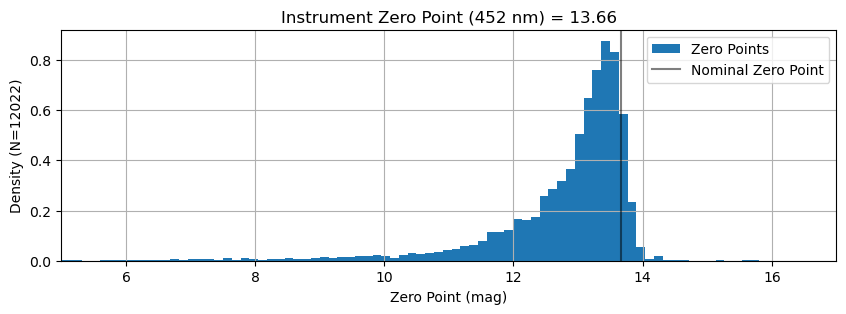

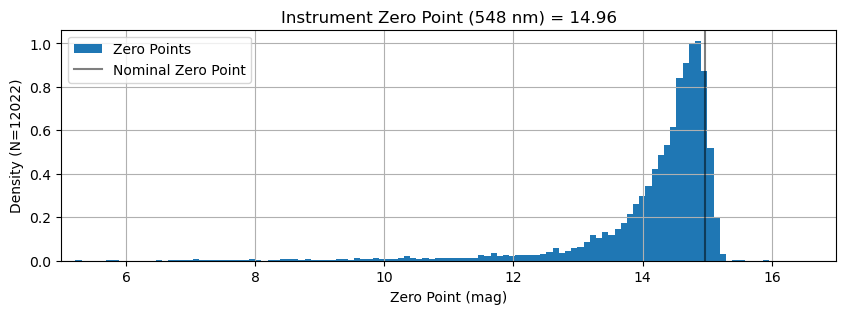

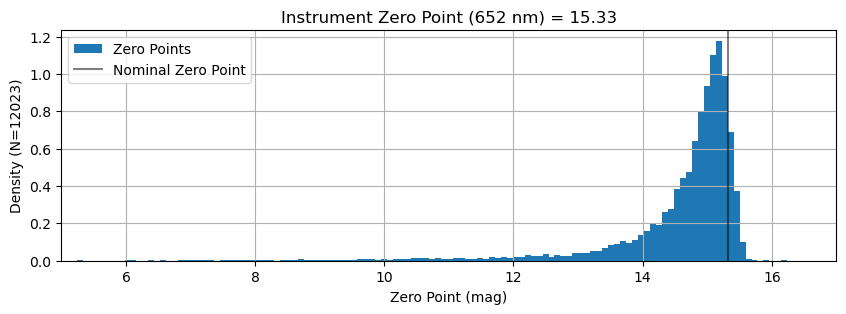

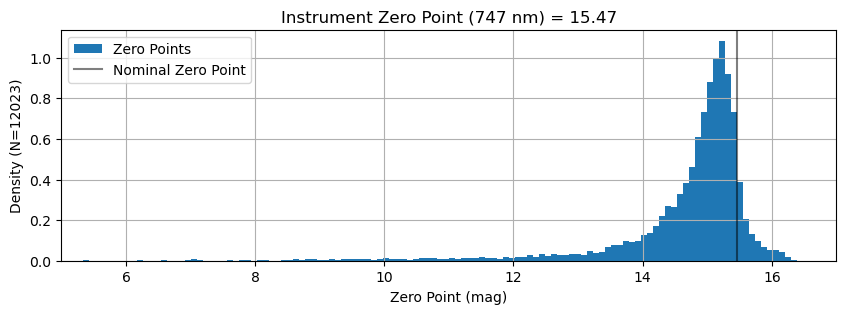

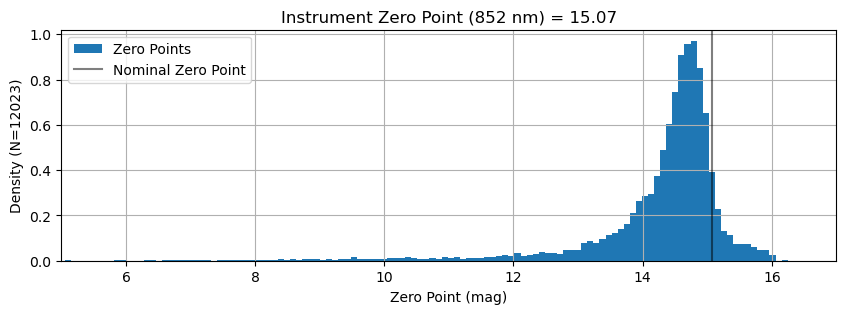

In [8]:
wavs = ['452', '548', '652', '747', '852']
ZeroPoint = {}
for wav in wavs:
    ZeroPoint[wav] = calculate_instrument_zero_point(t, wav=wav, percentile=90, plot=True)

### Discussion

As with the Exposure Meter, the distribution of individual zero point values follows roughly what one might expect: a peak at high zero point corresponding to good (cloudless) conditions.  The width of that peak is probably related to the seeing distribution of these observations.  The long tail of zero points at lower values correspond to cloudy nights with poor throughput.

Similar to the Exposure Meter's "bin 4" behavior, the longer wavelengths have a stronger tail to very high zero points.


In [9]:
ZeroPoint

{'452': 13.664278495210038,
 '548': 14.964690898633878,
 '652': 15.329155098901115,
 '747': 15.466755734095996,
 '852': 15.073233551565435}

## Check for Evolution Over Time

We bin the zero point values by day (MJD) to see if we can discern any time evolution.  For the main spectrograph, this is obscured by the fact that data were reduced with different versions of the DRP, which can perform differently at the extraction step.  We'll color code each of the major DRP versions and slice the data by both day and DRP version.

/Users/jwalawender/miniforge3/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


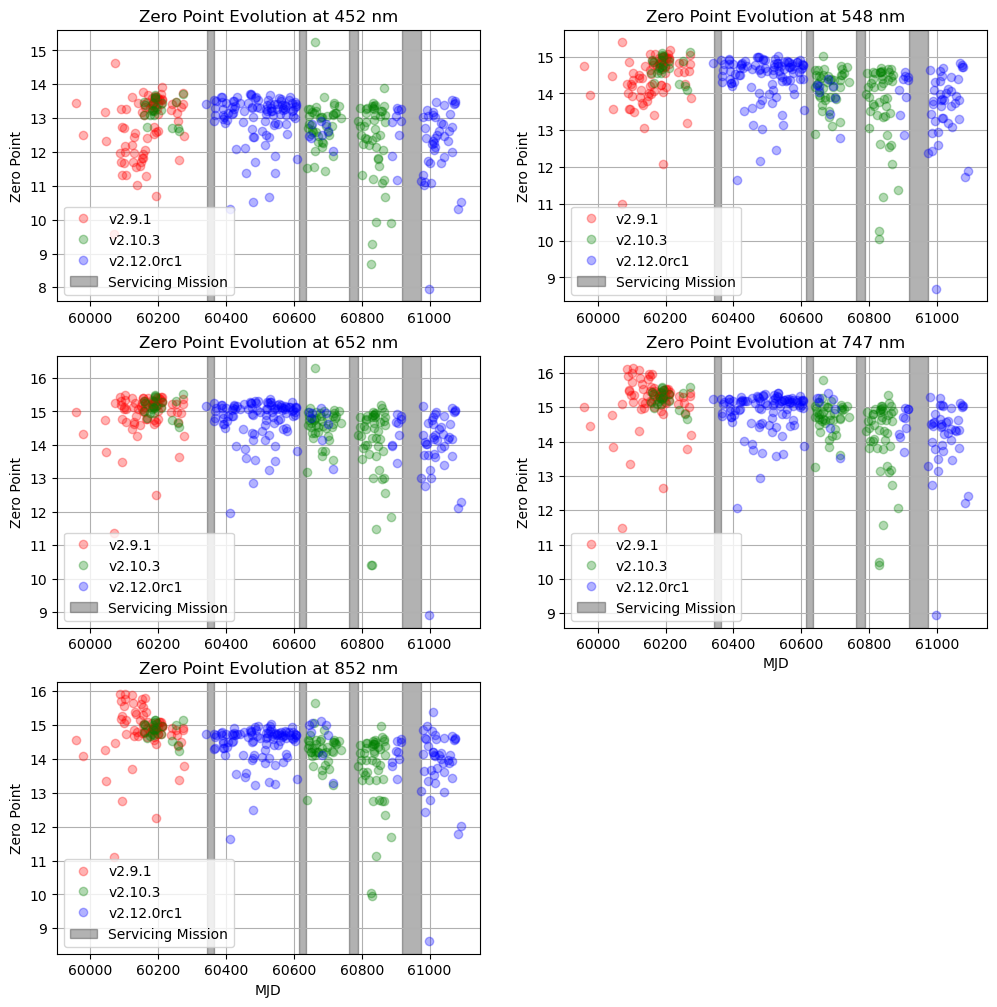

In [10]:
wav = '652'
mjd = np.array([int(d) for d in t['MJD-OBS']])

plt.figure(figsize=(12,12))

for w,wav in enumerate(wavs):
    plt.subplot(3,2,w+1)
    plt.title(f'Zero Point Evolution at {wav} nm')
    drpvs = ['v2.9.1', 'v2.10.3', 'v2.12.0rc1']
    for i,drpv in enumerate(drpvs):
        color = ['r', 'g', 'b'][i]
        labeled = False
        for j,day in enumerate(set(mjd)):
            wday = np.where((mjd == day) & (t['DRPTAGL2'] == drpv))
            if len(wday[0]) > 0:
                day_zp = np.median(t[f'ZP_{wav}'][wday])
                if not labeled:
                    plt.plot(day, day_zp, f'{color}o', alpha=0.3, label=f'{drpvs[i]}')
                    labeled = True
                else:
                    plt.plot(day, day_zp, f'{color}o', alpha=0.3)
    plt.axvspan(SM1start.mjd, SM1end.mjd, color='k', alpha=0.3, label='Servicing Mission')
    plt.axvspan(SM2start.mjd, SM2end.mjd, color='k', alpha=0.3)
    plt.axvspan(SM3start.mjd, SM3end.mjd, color='k', alpha=0.3)
    plt.axvspan(SM4start.mjd, SM4end.mjd, color='k', alpha=0.3)
    if w in [3, 4]: plt.xlabel('MJD')
    plt.ylabel('Zero Point')
    plt.grid()
    plt.legend(loc='best')

plt.show()

### Discussion

Because the DRP version occurance roughly tracks the KPF Era, it is hard to be conclusive about time evolution, but there appears to be a general downward trend.  When comparing KPF Era 2.0 and 4.0 which both dominantly use v2.12.0rc1, there does appears to be a downward step in zero points.

# Save Results to Disk

In [11]:
t.write('data/Feb2026_withInstZPs.csv', overwrite=True)

In [12]:
ZPfile = Path('data/InstrumentZeroPoints.yaml')
if ZPfile.exists(): ZPfile.unlink()
with open(ZPfile, 'w') as f:
    f.write(yaml.dump(ZeroPoint))